# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


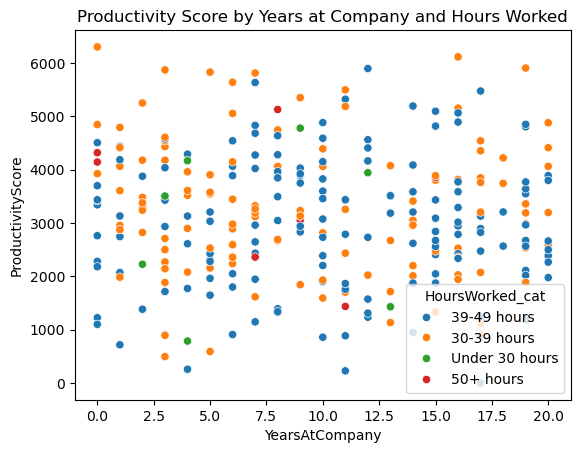

In [36]:
df['HoursWorked_cat']='Under 30 hours'
df.loc[(df['HoursWorked'] >= 30) & (df['HoursWorked'] < 40), 'HoursWorked_cat']= '30-39 hours'
df.loc[(df['HoursWorked'] >= 40) & (df['HoursWorked'] < 50), 'HoursWorked_cat']= '39-49 hours'
df.loc[(df['HoursWorked'] >= 50), 'HoursWorked_cat']= '50+ hours'

sns.scatterplot(x='YearsAtCompany', y='ProductivityScore', hue='HoursWorked_cat', data=df)
plt.title('Productivity Score by Years at Company and Hours Worked')
plt.show()


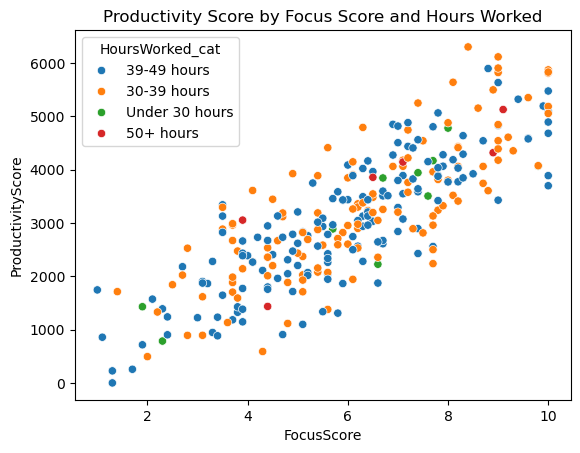

In [38]:
sns.scatterplot(x='FocusScore', y='ProductivityScore', hue='HoursWorked_cat', data=df)
plt.title('Productivity Score by Focus Score and Hours Worked')
plt.show()

In [40]:
import statsmodels.api as sm

X = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Sun, 21 Sep 2025   Prob (F-statistic):           3.02e-75
Time:                        19:25:54   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
import statsmodels.api as sm

X = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.726
Time:                        15:30:15   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [44]:
import statsmodels.api as sm

X = sm.add_constant(df['HoursWorked'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.379
Time:                        19:26:43   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

1) Focus Score has the stronger of the linear relationship with productivity. It also has the highest R-squared result as well.

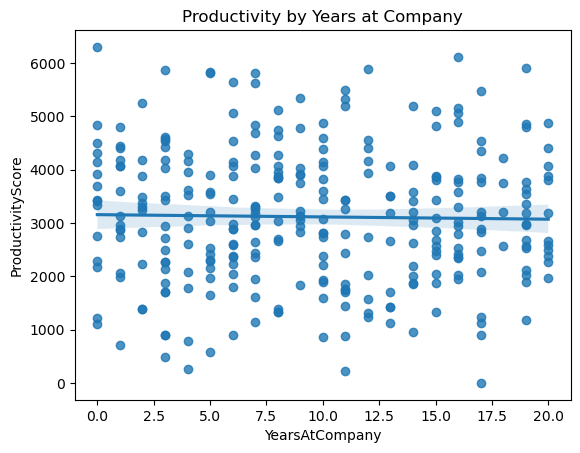

In [46]:
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df)
plt.title('Productivity by Years at Company')
plt.show()


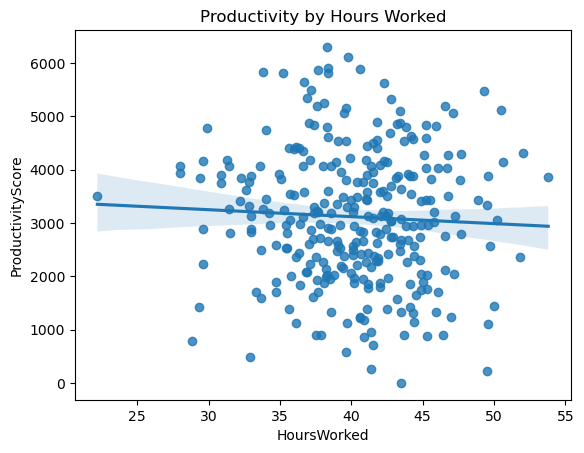

In [48]:
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df)
plt.title('Productivity by Hours Worked')
plt.show()


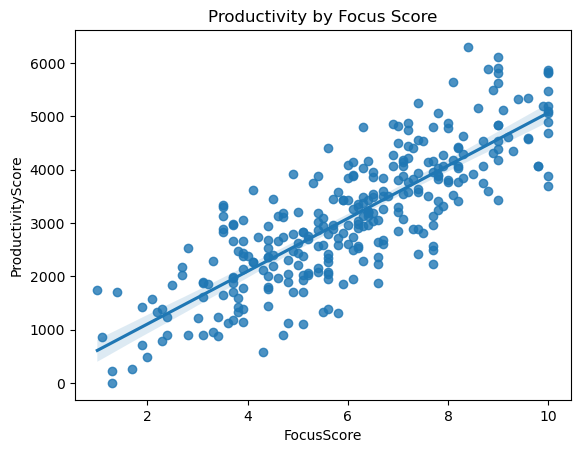

In [56]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Productivity by Focus Score')
plt.show()


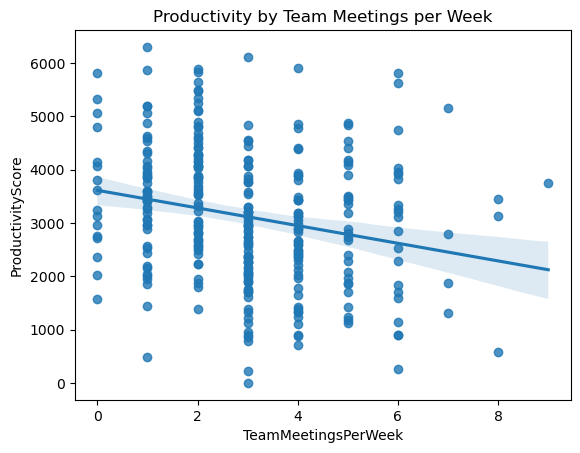

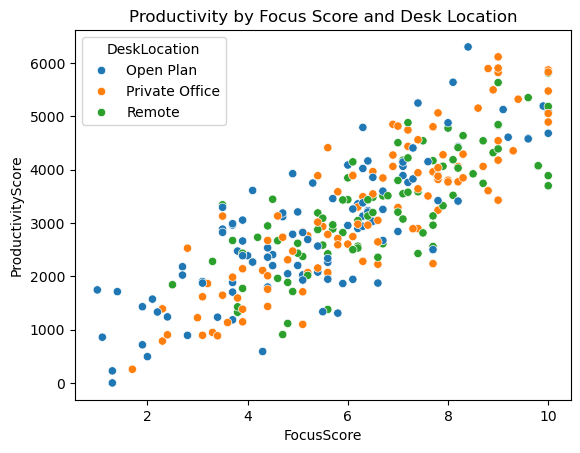

In [58]:
sns.scatterplot(x='FocusScore', y='ProductivityScore', data=df, hue="DeskLocation")
plt.title('Productivity by Focus Score and Desk Location')
plt.show()


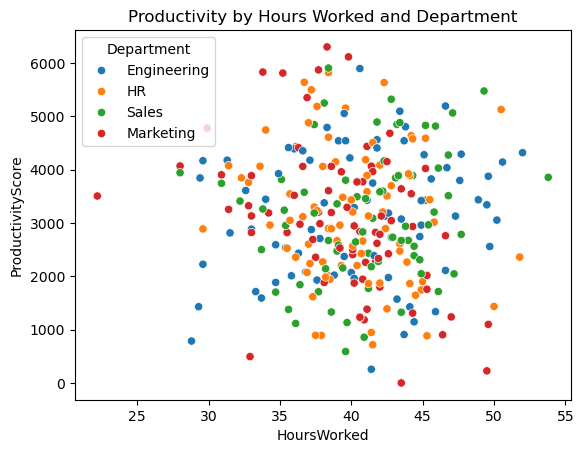

In [60]:
sns.scatterplot(x='HoursWorked', y='ProductivityScore', data=df, hue="Department")
plt.title('Productivity by Hours Worked and Department')
plt.show()


In [64]:
X = sm.add_constant(df[["TeamMeetingsPerWeek"]])
y = df["ProductivityScore"]

model = sm.OLS(y, X).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     17.09
Date:                Sun, 21 Sep 2025   Prob (F-statistic):           4.63e-05
Time:                        19:48:44   Log-Likelihood:                -2555.8
No. Observations:                 300   AIC:                             5116.
Df Residuals:                     298   BIC:                             5123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3611.2745    139.247     25.934      0.000    3337.243    3885.306
TeamMeetingsPerWeek  -165.5197     40.036     -4.134      0.000    -244.309     -86.730
==============================================================================
Omnibus:                        2.592   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.274   Jarque-Bera (JB):                2.468
Skew:                           0.157   Prob(JB):                        0.291
Kurtosis:                       2.686   Cond. No.                         7.33
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

2) The only other one I was able to get to work was the team meetings which shows the more meetings there are the less productive people get. Granted the regression line is not the best for most of these other than the FocusScore.

3) When I analyzed the data, I found that Focus Score has the strongest relationship with productivity. Employees who are able to concentrate more tend to be much more productive. On the other hand, hours worked and years at the company don’t seem to make much difference, which suggests that just putting in more hours or being more experienced at the company doesn’t automatically improve output. I also noticed that team meetings per week are negatively related to productivity, and employees in private offices or working remotely generally perform better than those in open-plan spaces.

Based on this, my recommendation is to help employees improve their ability to focus, cut down on unnecessary meetings, and consider providing more private or flexible work environments instead of expecting longer hours or tenure to raise productivity.